### LOADING CLUSTER 2 and CONFIG

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

PROCESSED_PATH = r'../../../processed_data' 
MODEL_SAVE_PATH = r'./model_checkpoints'

print("Loading FD003 Specialist 1 (Cluster 1) Data...")
try:
    X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD003_c1.npy'))
    y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD003_c1.npy'))
    print(f"Success! Training Shape: {X_train.shape}")
except FileNotFoundError:
    print("ERROR: Could not find files. Please check your path.")

Loading FD003 Specialist 1 (Cluster 1) Data...
Success! Training Shape: (9635, 30, 20)


### ATTENTION LAYER

In [2]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### BUILDING MODEL

In [3]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(128, return_sequences=True, name='lstm_layer')(inputs)
    x = Dropout(0.3)(x)
    x = Attention(name='attention_layer')(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 30, 20)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_layer (LSTM)                    │ (None, 30, 128)             │          76,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (Attention)          │ (None, 128)                 │             158 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,815 (339.12 KB)

 Trainable params: 86,815 (339.12 KB)

 Non-trainable params: 0 (0.00 B)

### TRAINING MODEL

In [4]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Starting Specialist 1 Training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2, 
    epochs=80, 
    batch_size=200, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Starting Specialist 1 Training...
Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 7916.8555 - mae: 78.6189 - val_loss: 3745.2427 - val_mae: 50.7248 - learning_rate: 0.0010
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 3569.1489 - mae: 50.9174 - val_loss: 1655.2900 - val_mae: 35.4490 - learning_rate: 0.0010
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 1868.9425 - mae: 38.0213 - val_loss: 1652.9847 - val_mae: 35.2821 - learning_rate: 0.0010
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 1820.6825 - mae: 37.3571 - val_loss: 1582.5957 - val_mae: 34.7811 - learning_rate: 0.0010
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 1780.2544 - mae: 37.2202 - val_loss: 1583.1371 - val_mae: 34.6030 - learning_rate: 0.0010
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 1616.8107 - mae: 35.2871 - val_loss: 1404.1483 - val_mae: 32.7865 - learning_rate: 0.0010
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 1446.4950 - m

### SAVING

In [5]:
model.save(os.path.join(MODEL_SAVE_PATH, 'specialist_1_fd003.keras'))
print("Specialist 1 Saved.")

Specialist 1 Saved.


### VISUALISING

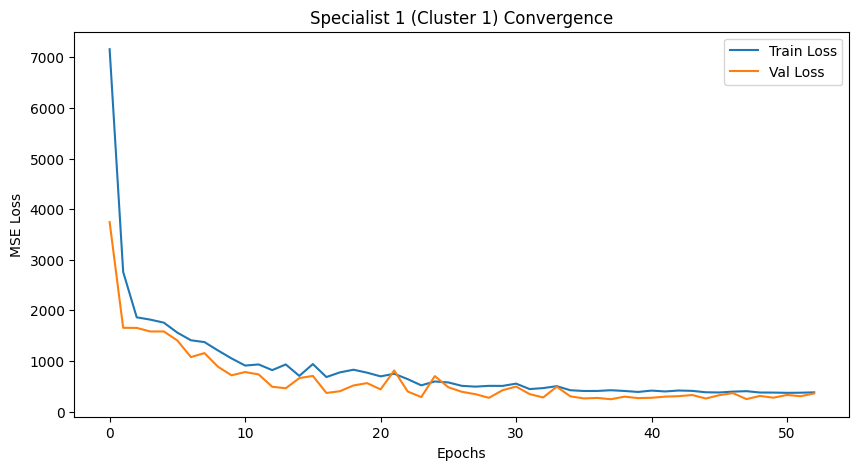

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Specialist 1 (Cluster 1) Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()